In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn plotly pyod joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import joblib
import json
import time

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

from pyod.models.iforest import IForest
from pyod.models.ocsvm   import OCSVM
from pyod.models.lof     import LOF
from pyod.models.knn     import KNN
from pyod.models.hbos    import HBOS
from pyod.models.pca     import PCA as PCA_OD
from pyod.models.cblof   import CBLOF
from pyod.models.copod   import COPOD
from pyod.models.ecod    import ECOD

from google.colab import files

warnings.filterwarnings("ignore")
np.random.seed(42)

COLORS = {
    "normal":  "#2ECC71",
    "anomaly": "#E74C3C",
    "EPS":     "#3498DB",
    "OBC":     "#9B59B6",
    "ADCS":    "#E67E22",
    "COMM":    "#1ABC9C",
    "bg":      "#0F1117",
}

plt.rcParams.update({
    "figure.facecolor": COLORS["bg"],
    "axes.facecolor":   COLORS["bg"],
    "axes.edgecolor":   "#2C3E50",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#2C3E50",
    "figure.dpi":       110,
    "font.size":        11,
})

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [4]:
df_raw = pd.read_csv('/content/EGSACUBE_v32_Telemetry (1).csv')

In [5]:
df_raw.shape

(663, 85)

In [6]:

print(f"\n  Frame Status Distribution:")
for status, count in df_raw['Status'].value_counts().items():
    pct = count / len(df_raw) * 100
    print(f"    {status[:40]:<42}: {count:>4}  ({pct:.1f}%)")


  Frame Status Distribution:
    Success                                   :  656  (98.9%)
    Frame too short: 10 bytes                 :    2  (0.3%)
    Frame too short: 46 bytes                 :    1  (0.2%)
    Frame too short: 47 bytes                 :    1  (0.2%)
    Frame too short: 9 bytes                  :    1  (0.2%)
    Frame too short: 11 bytes                 :    1  (0.2%)
    Frame too short: 14 bytes                 :    1  (0.2%)


In [7]:
df_raw.head()

,Line,Timestamp,Hex,Status,Frame_Type,Frame_Kind,Sat_ID,EPS_Address,EPS_Mode,EPS_Mode_Name,...,COMM_RSSI,COMM_RF_Temp,COMM_RX_Current,COMM_TX_I_3V3,COMM_TX_I_5V,SW_Seq_Number,SW_In_Eclipse,SW_In_Safe_Mode,SW_HW_ABF,SW_SW_ABF
0,1,2026-02-20 12:42:31,910F1C11020F43013C1F3400C005BF0000111111110000...,Success,17.0,HR,2.0,0xa2,3.0,Normal,...,108.0,178.0,131.0,225.0,194.0,9457980.0,True,True,True,True
1,2,2026-02-20 12:41:46,880E310FAD0F11016C1F3E00B705BF0000111011100000...,Success,8.0,WO,2.0,0xa2,3.0,Normal,...,108.0,194.0,132.0,1.0,195.0,9457980.0,True,True,True,True
2,3,2026-02-20 11:04:43,900E310EA10EA601CD1F5200DB05BF0000100F100F0000...,Success,16.0,FM,2.0,0xa2,3.0,Normal,...,92.0,210.0,132.0,145.0,196.0,9445436.0,True,True,True,True
3,4,2026-02-20 11:04:38,8F0E310E200E3101951F3E00E005BF0000100F100F0000...,Success,15.0,FM,2.0,0xa2,3.0,Normal,...,92.0,210.0,132.0,193.0,212.0,9445436.0,True,True,True,True
4,5,2026-02-20 11:04:33,8E0E310E690E31016A1F3400D705BF0000100F0F0F0000...,Success,14.0,FM,2.0,0xa2,3.0,Normal,...,92.0,194.0,132.0,161.0,212.0,9445436.0,True,True,True,True


In [8]:
# EPS — Electrical Power System
EPS_FEATS = [
    "EPS_Solar_1_V", "EPS_Solar_2_V", "EPS_Solar_3_V",
    "EPS_Solar_1_C", "EPS_Solar_2_C", "EPS_Solar_3_C",
    "EPS_VBAT", "EPS_IBAT",
    "EPS_BUS_1_V", "EPS_BUS_2_V",
    "EPS_BUS_1_C", "EPS_BUS_2_C",
    "EPS_Temp",
]

# OBC — On-Board Computer
OBC_FEATS = [
    "OBC_Latitude", "OBC_Longitude",
    "OBC_velN", "OBC_velE", "OBC_velD",
    "OBC_RX_CMD_Count", "OBC_TX_CMD_Count",
    "OBC_EPS_SRecords", "OBC_ADCS_SRecords",
]

# ADCS — Attitude Determination & Control System
ADCS_FEATS = [
    "ADCS_Sun_X", "ADCS_Sun_Y", "ADCS_Sun_Z",
    "ADCS_accel_x", "ADCS_accel_y", "ADCS_accel_z",
    "ADCS_Gyro_X", "ADCS_Gyro_Y", "ADCS_Gyro_Z",
    "ADCS_MM_X", "ADCS_MM_Y", "ADCS_MM_Z",
    "ADCS_RW_RPM",
]

# COMM — Communication Subsystem
COMM_FEATS = [
    "COMM_Total_RX", "COMM_Correct_RX",
    "COMM_RF_Power", "COMM_RSSI",
    "COMM_RF_Temp",
    "COMM_RX_Current", "COMM_TX_I_3V3", "COMM_TX_I_5V",
]

ALL_FEATS = EPS_FEATS + OBC_FEATS + ADCS_FEATS + COMM_FEATS

df = df_raw[df_raw["Status"] == "Success"].copy()

df = df[[c for c in ALL_FEATS if c in df.columns]].apply(
    pd.to_numeric, errors="coerce"
)
df.dropna(how="all", axis=1, inplace=True)
ALL_FEATS = [c for c in ALL_FEATS if c in df.columns]

print("=" * 55)
print("  FEATURE GROUPS SUMMARY")
print("=" * 55)
for name, feats in [("EPS", EPS_FEATS), ("OBC", OBC_FEATS),
                    ("ADCS", ADCS_FEATS), ("COMM", COMM_FEATS)]:
    available = [c for c in feats if c in df.columns]
    print(f"  {name:<6}: {len(available):>2} features available")
print(f"\n  Total features : {len(ALL_FEATS)}")
print(f"  Total rows     : {len(df)}")
print("=" * 55)

  FEATURE GROUPS SUMMARY
  EPS   : 13 features available
  OBC   :  9 features available
  ADCS  : 13 features available
  COMM  :  8 features available

  Total features : 43
  Total rows     : 656


# EDA: Basic Statistics

In [9]:
print("📊 Basic Statistics (first 10 features):")
print(df[ALL_FEATS[:10]].describe().round(2).to_string())

📊 Basic Statistics (first 10 features):
       EPS_Solar_1_V  EPS_Solar_2_V  EPS_Solar_3_V  EPS_Solar_1_C  EPS_Solar_2_C  EPS_Solar_3_C  EPS_VBAT  EPS_IBAT  EPS_BUS_1_V  EPS_BUS_2_V
count          656.0         656.00         656.00         656.00         656.00         656.00    656.00    656.00       656.00       656.00
mean          2209.2        2207.73        2193.12         331.79         331.44         329.03   8000.04    189.87      3299.41      4998.26
std           1889.0        1900.58        1879.59         282.28         284.00         280.95     66.82     23.28        19.61        30.47
min              0.0           0.00           0.00           0.00           0.00           0.00   7876.00    141.00      3240.00      4904.00
25%              0.0           0.00           0.00           2.00           2.00           1.00   7937.00    169.00      3286.00      4978.00
50%           3633.0        3616.00        3633.00         543.00         540.00         542.00   7998.00   

# EDA: Feature Distributions per Subsystem

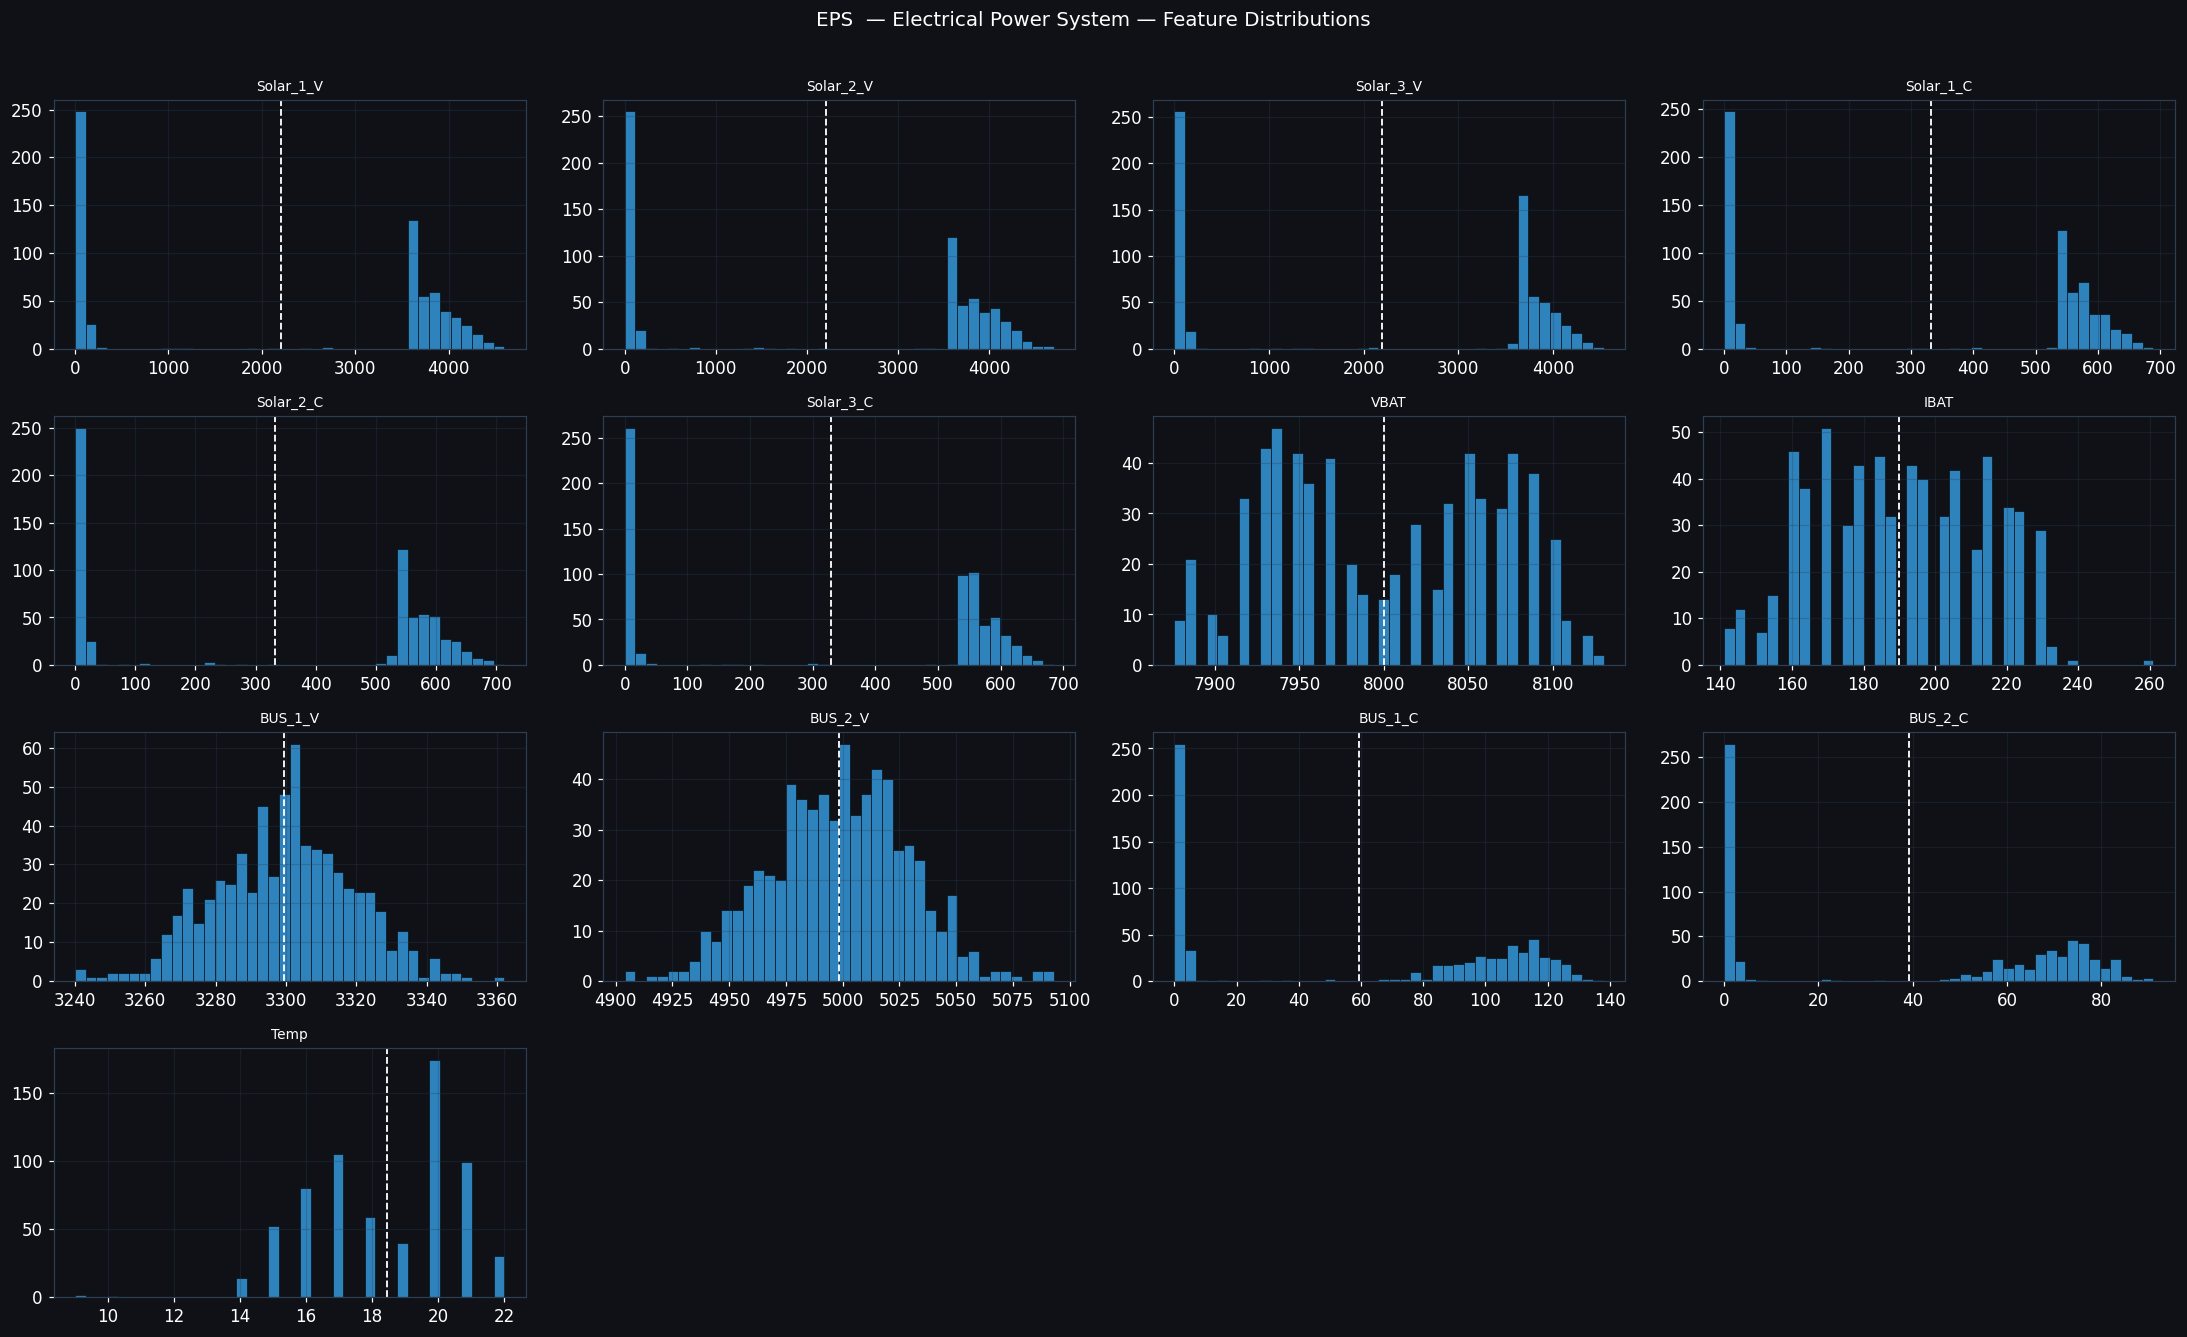

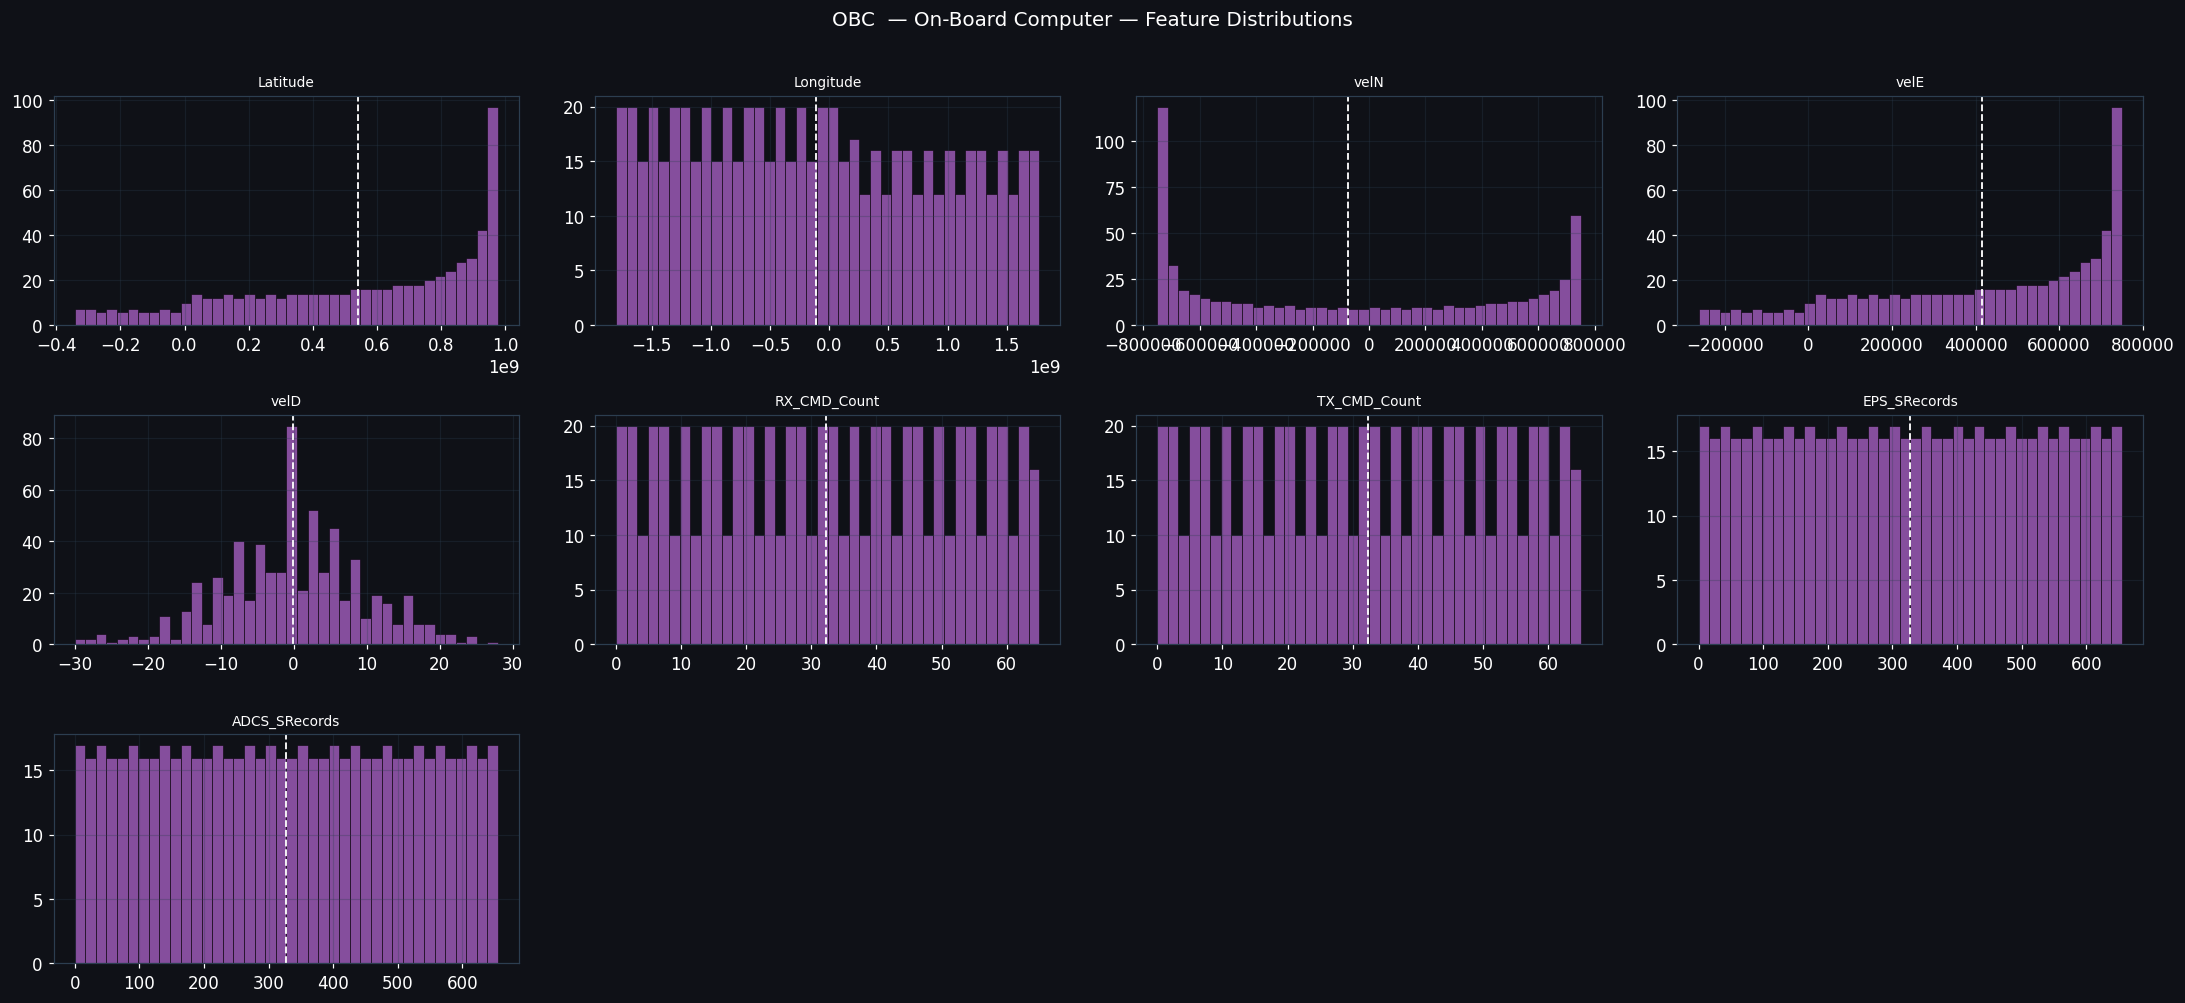

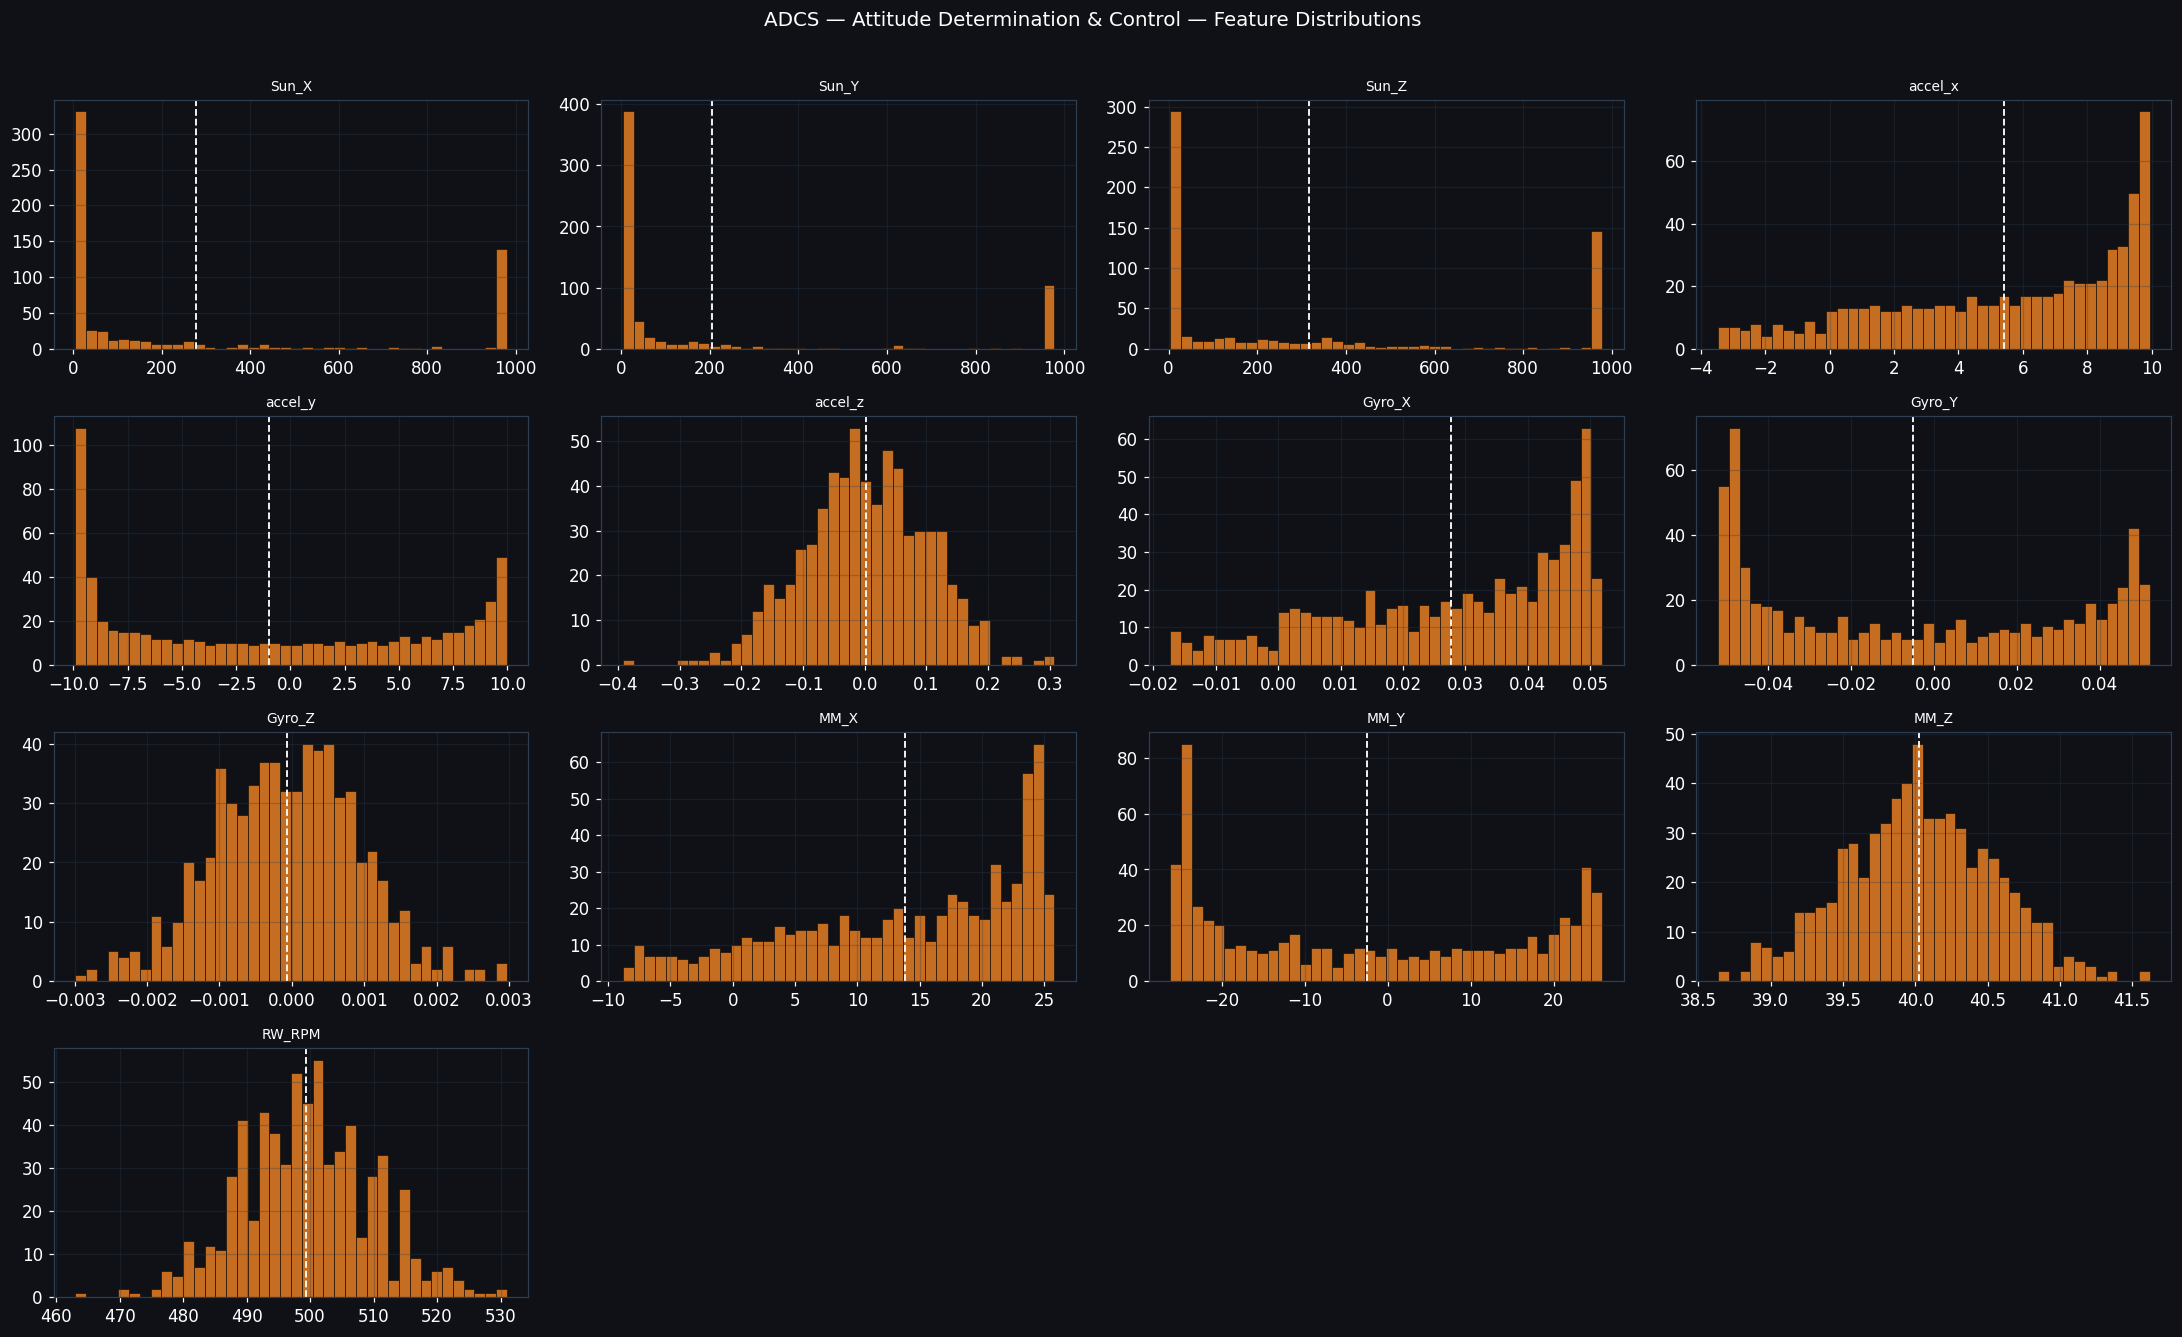

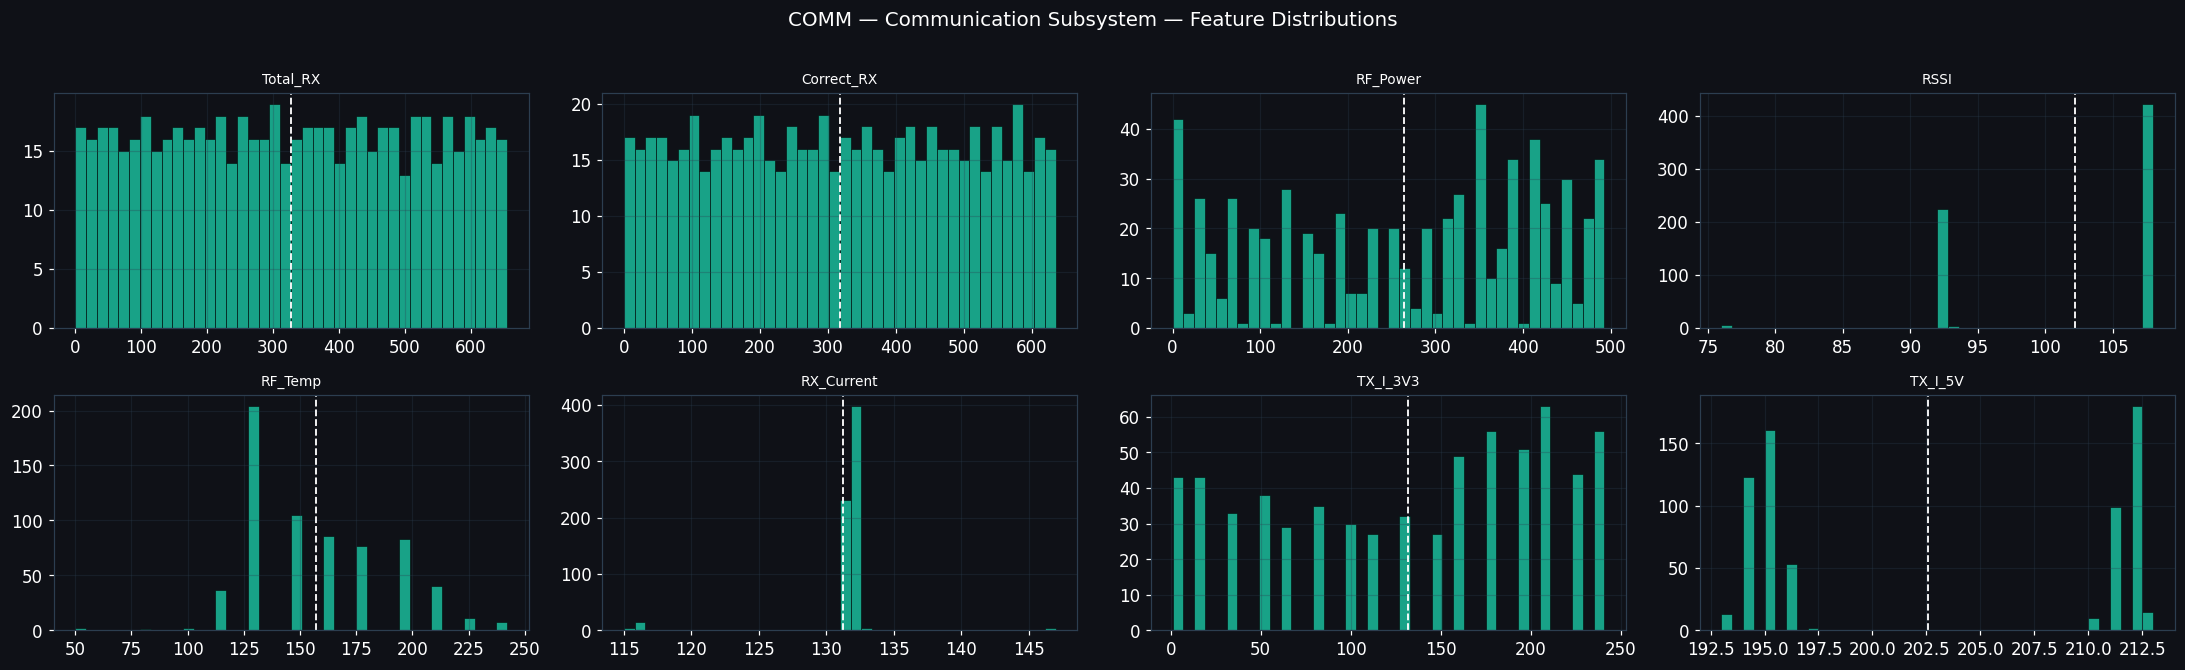

In [10]:
subsystems = {
    "EPS  — Electrical Power System":            [c for c in EPS_FEATS  if c in df.columns],
    "OBC  — On-Board Computer":                  [c for c in OBC_FEATS  if c in df.columns],
    "ADCS — Attitude Determination & Control":   [c for c in ADCS_FEATS if c in df.columns],
    "COMM — Communication Subsystem":            [c for c in COMM_FEATS if c in df.columns],
}
subsystem_colors = {
    "EPS  — Electrical Power System":          COLORS["EPS"],
    "OBC  — On-Board Computer":                COLORS["OBC"],
    "ADCS — Attitude Determination & Control": COLORS["ADCS"],
    "COMM — Communication Subsystem":          COLORS["COMM"],
}

for title, feats in subsystems.items():
    if not feats:
        continue
    n_cols = 4
    n_rows = (len(feats) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(20, n_rows * 3))
    axes = axes.flatten()
    clr  = subsystem_colors[title]

    for i, col in enumerate(feats):
        data = df[col].dropna()
        axes[i].hist(data, bins=40, color=clr, alpha=0.85,
                     edgecolor="black", linewidth=0.4)
        axes[i].axvline(data.mean(), color="white",
                        linestyle="--", linewidth=1.2, label="mean")
        axes[i].set_title(col.split("_", 1)[-1], fontsize=9)
        axes[i].grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{title} — Feature Distributions",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# EDA: Boxplots

In [11]:
sub_map = {
    "EPS":  [c for c in EPS_FEATS  if c in df.columns],
    "OBC":  [c for c in OBC_FEATS  if c in df.columns],
    "ADCS": [c for c in ADCS_FEATS if c in df.columns],
    "COMM": [c for c in COMM_FEATS if c in df.columns],
}

for name, feats in sub_map.items():
    if not feats:
        continue
    data = df[feats].copy()
    fig  = px.box(
        data, title=f"📦 {name} Subsystem — Boxplots (Outlier View)",
        color_discrete_sequence=[COLORS[name]],
        points="outliers",
    )
    fig.update_layout(
        paper_bgcolor=COLORS["bg"], plot_bgcolor=COLORS["bg"],
        font_color="white", height=420,
        xaxis_tickangle=-40,
        margin=dict(b=120),
    )
    fig.show()

# EDA: Correlation Heatmap

In [12]:
corr = df[ALL_FEATS].corr()

fig = px.imshow(
    corr,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="🔗 Feature Correlation Matrix — All Subsystems",
)
fig.update_layout(
    width=1100, height=950,
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["bg"],
    font_color="white",
)
fig.show()

# corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
#                   .stack()
#                   .reset_index())
# corr_pairs.columns = ["Feature A", "Feature B", "Correlation"]
# corr_pairs["Abs"] = corr_pairs["Correlation"].abs()
# high_corr = corr_pairs[corr_pairs["Abs"] > 0.8].sort_values("Abs", ascending=False)

# if len(high_corr):
#     print(f"⚠️  Highly correlated feature pairs (|r| > 0.8): {len(high_corr)}")
#     print(high_corr[["Feature A","Feature B","Correlation"]].to_string(index=False))
# else:
#     print("✅ No highly correlated pairs found (|r| > 0.8)")

#  EDA: Time-Series Key Channels

In [13]:
key_channels = [
    ("EPS_VBAT",      COLORS["EPS"],  "Battery Voltage (EPS)"),
    ("EPS_Solar_1_V", COLORS["EPS"],  "Solar Panel 1 Voltage (EPS)"),
    ("ADCS_Gyro_X",   COLORS["ADCS"], "Gyroscope X (ADCS)"),
    ("ADCS_MM_X",     COLORS["ADCS"], "Magnetometer X (ADCS)"),
    ("COMM_RSSI",     COLORS["COMM"], "RSSI (COMM)"),
    ("OBC_Latitude",  COLORS["OBC"],  "GPS Latitude (OBC)"),
]
key_channels = [(c, cl, lb) for c, cl, lb in key_channels
                if c in df.columns]

fig = make_subplots(
    rows=len(key_channels), cols=1,
    shared_xaxes=True,
    subplot_titles=[lb for _, _, lb in key_channels],
    vertical_spacing=0.06,
)

for i, (col, clr, lbl) in enumerate(key_channels, 1):
    fig.add_trace(
        go.Scatter(
            y=df[col].values,
            mode="lines",
            line=dict(color=clr, width=1.3),
            name=lbl,
        ),
        row=i, col=1,
    )

fig.update_layout(
    height=950,
    showlegend=False,
    title="📈 Key Telemetry Channels Over Time (All Frames)",
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["bg"],
    font_color="white",
)
fig.show()

# EDA: PCA Variance Analysis

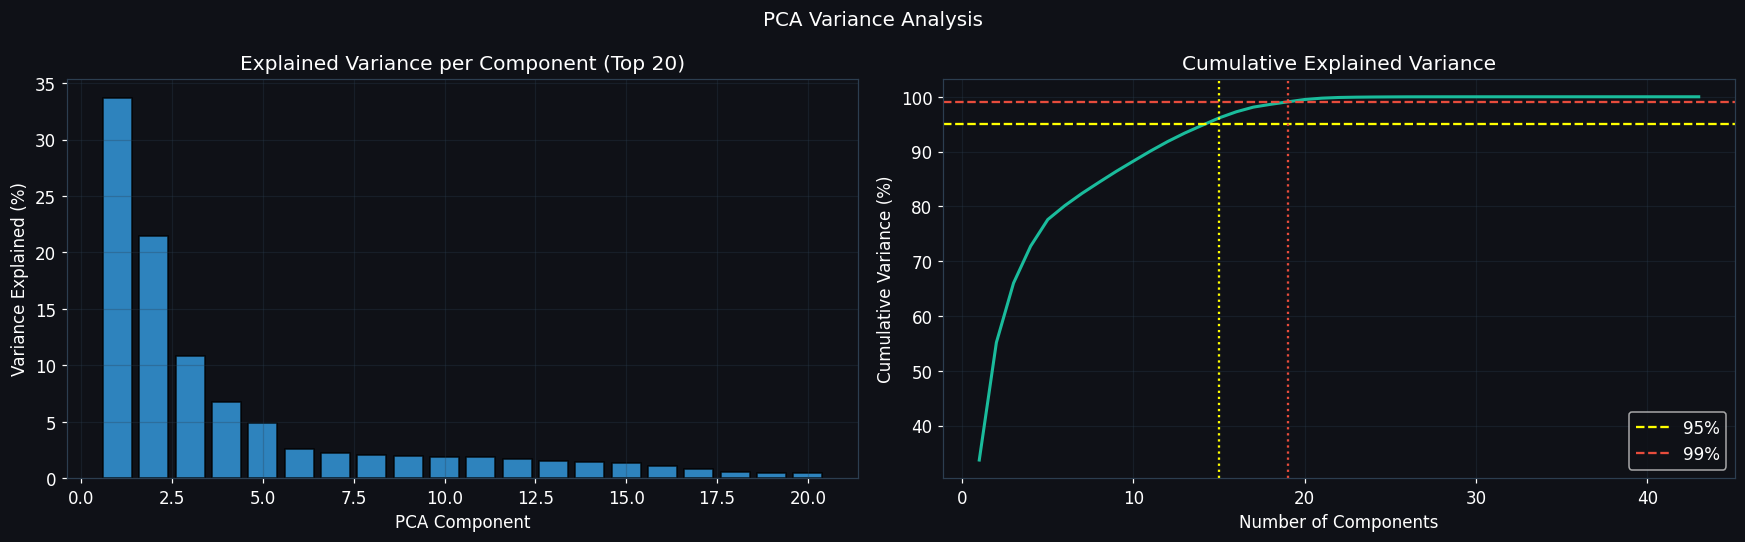

In [14]:
df_num = df[ALL_FEATS].fillna(df[ALL_FEATS].median())
scaler_eda = RobustScaler()
X_eda = scaler_eda.fit_transform(df_num)

pca_full = PCA(random_state=42)
pca_full.fit(X_eda)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95   = np.argmax(cumvar >= 95) + 1
n_99   = np.argmax(cumvar >= 99) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# left: variance per component (top 20)
axes[0].bar(
    range(1, min(21, len(cumvar) + 1)),
    pca_full.explained_variance_ratio_[:20] * 100,
    color=COLORS["EPS"], alpha=0.85, edgecolor="black",
)
axes[0].set_title("Explained Variance per Component (Top 20)")
axes[0].set_xlabel("PCA Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].grid(True, alpha=0.3)

# right: cumulative variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar,
             color=COLORS["COMM"], linewidth=2)
axes[1].axhline(95, color="yellow",        linestyle="--", linewidth=1.5, label="95%")
axes[1].axhline(99, color=COLORS["anomaly"],linestyle="--", linewidth=1.5, label="99%")
axes[1].axvline(n_95, color="yellow",       linestyle=":", linewidth=1.5)
axes[1].axvline(n_99, color=COLORS["anomaly"],linestyle=":", linewidth=1.5)
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("PCA Variance Analysis", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
print(f"\n📊 PCA Summary:")
print(f"  Components for 95% variance : {n_95}")
print(f"  Components for 99% variance : {n_99}")
print(f"  Total features              : {len(ALL_FEATS)}")
print(f"  Dimensionality reduction    : {len(ALL_FEATS)} → {n_95} ({n_95/len(ALL_FEATS)*100:.0f}% of original)")


📊 PCA Summary:
  Components for 95% variance : 15
  Components for 99% variance : 19
  Total features              : 43
  Dimensionality reduction    : 43 → 15 (35% of original)


# Data Cleaning

In [16]:
print("BEFORE CLEANING")
print(f"  Rows         : {len(df)}")
print(f"  NaN total    : {df[ALL_FEATS].isnull().sum().sum()}")
print(f"  Features     : {len(ALL_FEATS)}")

df_clean = df[ALL_FEATS].copy()

# Step 1: fill NaN with median
df_clean.fillna(df_clean.median(), inplace=True)

# Step 2: clip extreme outliers (5× IQR fence)
Q1  = df_clean.quantile(0.25)
Q3  = df_clean.quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean.clip(lower=Q1 - 5*IQR,
                         upper=Q3 + 5*IQR, axis=1)

# Step 3: remove constant columns
const_cols = [c for c in df_clean.columns
              if df_clean[c].std() == 0]
df_clean.drop(columns=const_cols, inplace=True)
ALL_FEATS_CLEAN = df_clean.columns.tolist()

print("\nAFTER CLEANING")
print(f"  Rows              : {len(df_clean)}")
print(f"  NaN total         : {df_clean.isnull().sum().sum()}")
print(f"  Removed (constant): {len(const_cols)}")
print(f"  Final features    : {len(ALL_FEATS_CLEAN)}")

BEFORE CLEANING
  Rows         : 656
  NaN total    : 0
  Features     : 43

AFTER CLEANING
  Rows              : 656
  NaN total         : 0
  Removed (constant): 0
  Final features    : 43


# Feature Engineering & Scaling


In [17]:
df_feat = df_clean.copy()

# EPS: solar power = voltage × current
for i in [1, 2, 3]:
    v_col = f"EPS_Solar_{i}_V"
    c_col = f"EPS_Solar_{i}_C"
    if v_col in df_feat.columns and c_col in df_feat.columns:
        df_feat[f"EPS_Solar_{i}_Power"] = df_feat[v_col] * df_feat[c_col]
        print(f"  ✅ Created EPS_Solar_{i}_Power")

# ADCS: gyroscope total magnitude = √(Gx² + Gy² + Gz²)
gyro_cols = ["ADCS_Gyro_X", "ADCS_Gyro_Y", "ADCS_Gyro_Z"]
if all(c in df_feat.columns for c in gyro_cols):
    df_feat["ADCS_Gyro_Magnitude"] = np.sqrt(
        df_feat["ADCS_Gyro_X"]**2 +
        df_feat["ADCS_Gyro_Y"]**2 +
        df_feat["ADCS_Gyro_Z"]**2
    )
    print("  ✅ Created ADCS_Gyro_Magnitude")

# ADCS: magnetometer total magnitude = √(Mx² + My² + Mz²)
mm_cols = ["ADCS_MM_X", "ADCS_MM_Y", "ADCS_MM_Z"]
if all(c in df_feat.columns for c in mm_cols):
    df_feat["ADCS_MM_Magnitude"] = np.sqrt(
        df_feat["ADCS_MM_X"]**2 +
        df_feat["ADCS_MM_Y"]**2 +
        df_feat["ADCS_MM_Z"]**2
    )
    print("  ✅ Created ADCS_MM_Magnitude")

# COMM: frame success rate = correct RX / total RX
if "COMM_Total_RX" in df_feat.columns and "COMM_Correct_RX" in df_feat.columns:
    df_feat["COMM_Success_Rate"] = np.where(
        df_feat["COMM_Total_RX"] > 0,
        df_feat["COMM_Correct_RX"] / df_feat["COMM_Total_RX"],
        0,
    )
    print("  ✅ Created COMM_Success_Rate")

FINAL_FEATS = df_feat.columns.tolist()

# ── Scale with RobustScaler (resistant to outliers) ───────────────
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(df_feat)

print(f"\n✅ Scaling done — RobustScaler")
print(f"   Final feature count : {len(FINAL_FEATS)}")
print(f"   Dataset shape       : {X_scaled.shape}")

  ✅ Created EPS_Solar_1_Power
  ✅ Created EPS_Solar_2_Power
  ✅ Created EPS_Solar_3_Power
  ✅ Created ADCS_Gyro_Magnitude
  ✅ Created ADCS_MM_Magnitude
  ✅ Created COMM_Success_Rate

✅ Scaling done — RobustScaler
   Final feature count : 49
   Dataset shape       : (656, 49)


# Lazy Predict

In [18]:
CONTAMINATION = 0.05   # expected anomaly rate (5%)

candidate_models = {
    "Isolation Forest": IForest(contamination=CONTAMINATION, random_state=42),
    "One-Class SVM":    OCSVM(contamination=CONTAMINATION),
    "LOF":              LOF(contamination=CONTAMINATION),
    "KNN":              KNN(contamination=CONTAMINATION),
    "HBOS":             HBOS(contamination=CONTAMINATION),
    "PCA-based":        PCA_OD(contamination=CONTAMINATION, random_state=42),
    "CBLOF":            CBLOF(contamination=CONTAMINATION, random_state=42),
    "COPOD":            COPOD(contamination=CONTAMINATION),
    "ECOD":             ECOD(contamination=CONTAMINATION),
}

results = []

print(f"{'Model':<22} {'Anomalies':>10} {'Rate %':>8} {'Time (s)':>10}  Status")
print("─" * 62)

for name, model in candidate_models.items():
    t0 = time.time()
    try:
        model.fit(X_scaled)
        preds   = model.labels_            # 0 = normal, 1 = anomaly
        scores  = model.decision_scores_
        n_anom  = int(preds.sum())
        rate    = round(n_anom / len(preds) * 100, 2)
        elapsed = round(time.time() - t0, 2)

        results.append({
            "Model":     name,
            "Anomalies": n_anom,
            "Rate_%":    rate,
            "Time_s":    elapsed,
            "Preds":     preds,
            "Scores":    scores,
            "Fitted":    model,
        })
        print(f"{name:<22} {n_anom:>10} {rate:>7.1f}% {elapsed:>9.2f}s  ✅")
    except Exception as e:
        print(f"{name:<22} {'—':>10} {'—':>8} {'—':>10}  ❌ {e}")

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Preds", "Scores", "Fitted"]}
    for r in results
])

print(f"\n✅ Lazy Predict complete — {len(results)} models evaluated")

Model                   Anomalies   Rate %   Time (s)  Status
──────────────────────────────────────────────────────────────
Isolation Forest               33     5.0%      0.71s  ✅
One-Class SVM                  33     5.0%      0.12s  ✅
LOF                            33     5.0%      0.04s  ✅
KNN                            33     5.0%      0.01s  ✅
HBOS                           33     5.0%     10.67s  ✅
PCA-based                      33     5.0%      0.02s  ✅
CBLOF                          33     5.0%      1.63s  ✅
COPOD                          33     5.0%      0.14s  ✅
ECOD                           33     5.0%      0.01s  ✅

✅ Lazy Predict complete — 9 models evaluated


In [19]:
fig = px.bar(
    results_df.sort_values("Anomalies"),
    x="Anomalies", y="Model", orientation="h",
    color="Rate_%", color_continuous_scale="Reds",
    text="Rate_%",
    title=f"🔍 Lazy Predict — Anomaly Rate per Model (target = {CONTAMINATION*100:.0f}%)",
)
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.update_layout(
    paper_bgcolor=COLORS["bg"], plot_bgcolor=COLORS["bg"],
    font_color="white", height=480,
    xaxis_title="Number of Anomalies Detected",
    yaxis_title="Model",
)
fig.show()

# Select Top 3

In [20]:
target_rate = CONTAMINATION * 100   # 5.0 %

# rank by deviation from target rate
results_df["Deviation"] = (results_df["Rate_%"] - target_rate).abs()
results_df_ranked = results_df.sort_values("Deviation").reset_index(drop=True)

top3_names = results_df_ranked.head(3)["Model"].tolist()

print("=" * 55)
print("  TOP 3 SELECTED MODELS")
print("  (ranked by proximity to target anomaly rate)")
print("=" * 55)
for rank, name in enumerate(top3_names, 1):
    row = results_df_ranked[results_df_ranked["Model"] == name].iloc[0]
    print(f"  #{rank}  {name:<22}"
          f"| Rate: {row['Rate_%']:>5.1f}%"
          f"| Deviation: {row['Deviation']:>4.1f}%"
          f"| Time: {row['Time_s']:>5.2f}s")
print("=" * 55)

  TOP 3 SELECTED MODELS
  (ranked by proximity to target anomaly rate)
  #1  Isolation Forest      | Rate:   5.0%| Deviation:  0.0%| Time:  0.71s
  #2  One-Class SVM         | Rate:   5.0%| Deviation:  0.0%| Time:  0.12s
  #3  LOF                   | Rate:   5.0%| Deviation:  0.0%| Time:  0.04s


# Train & Evaluate Top 3

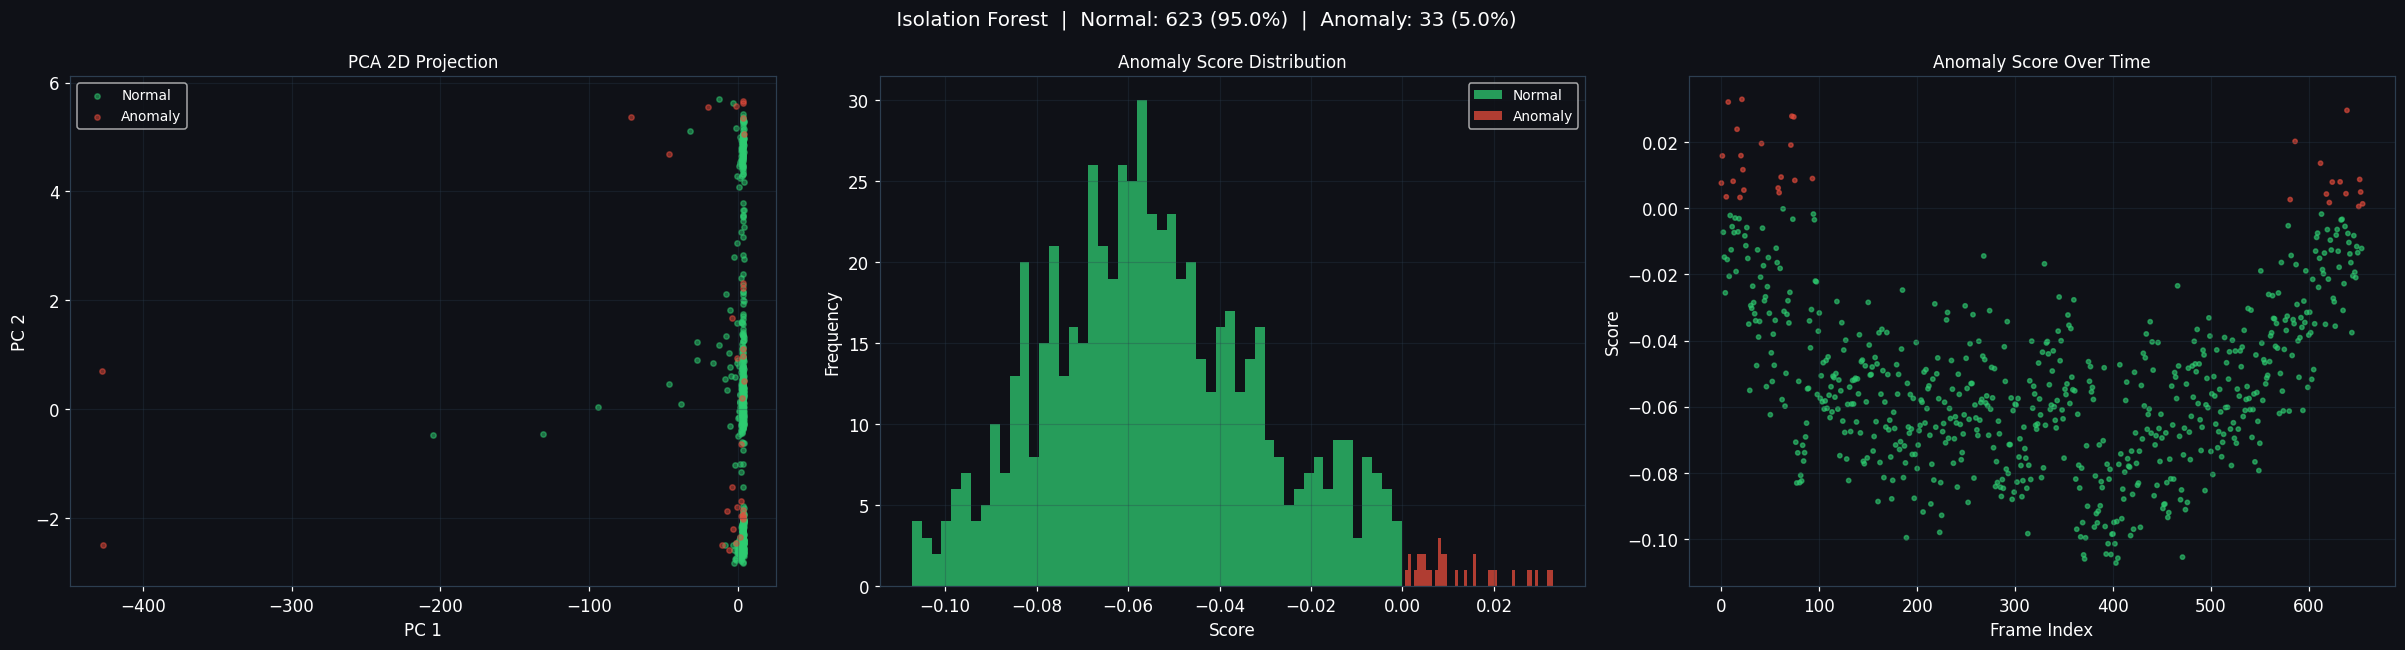

  ✅ Isolation Forest evaluation done



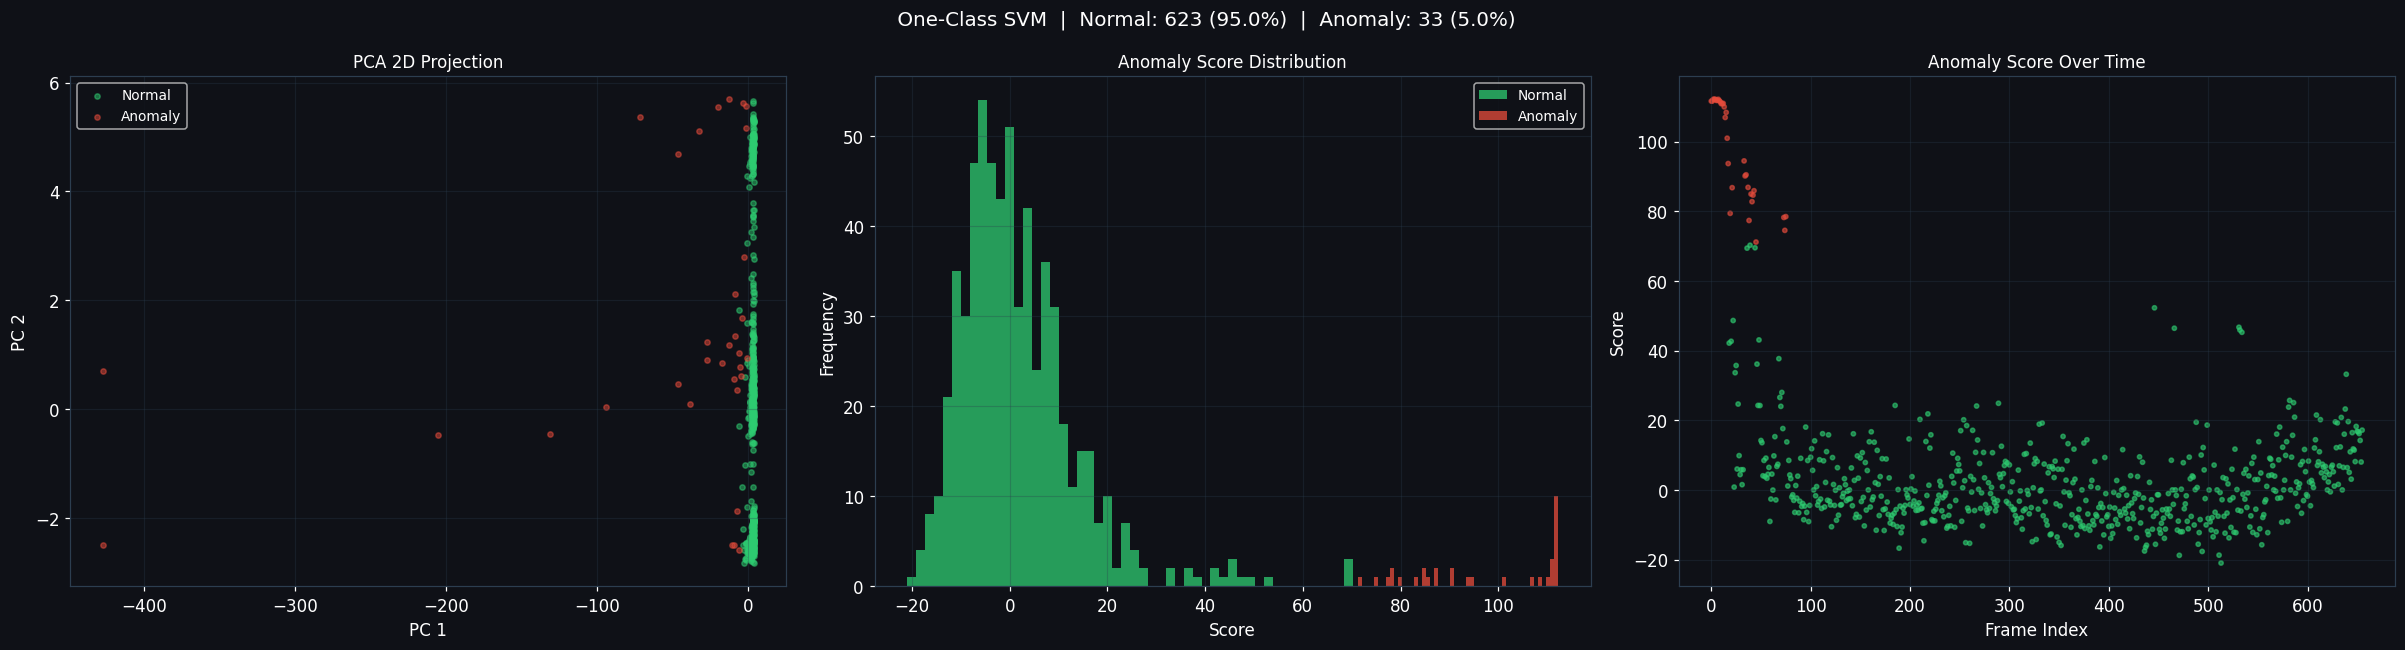

  ✅ One-Class SVM evaluation done



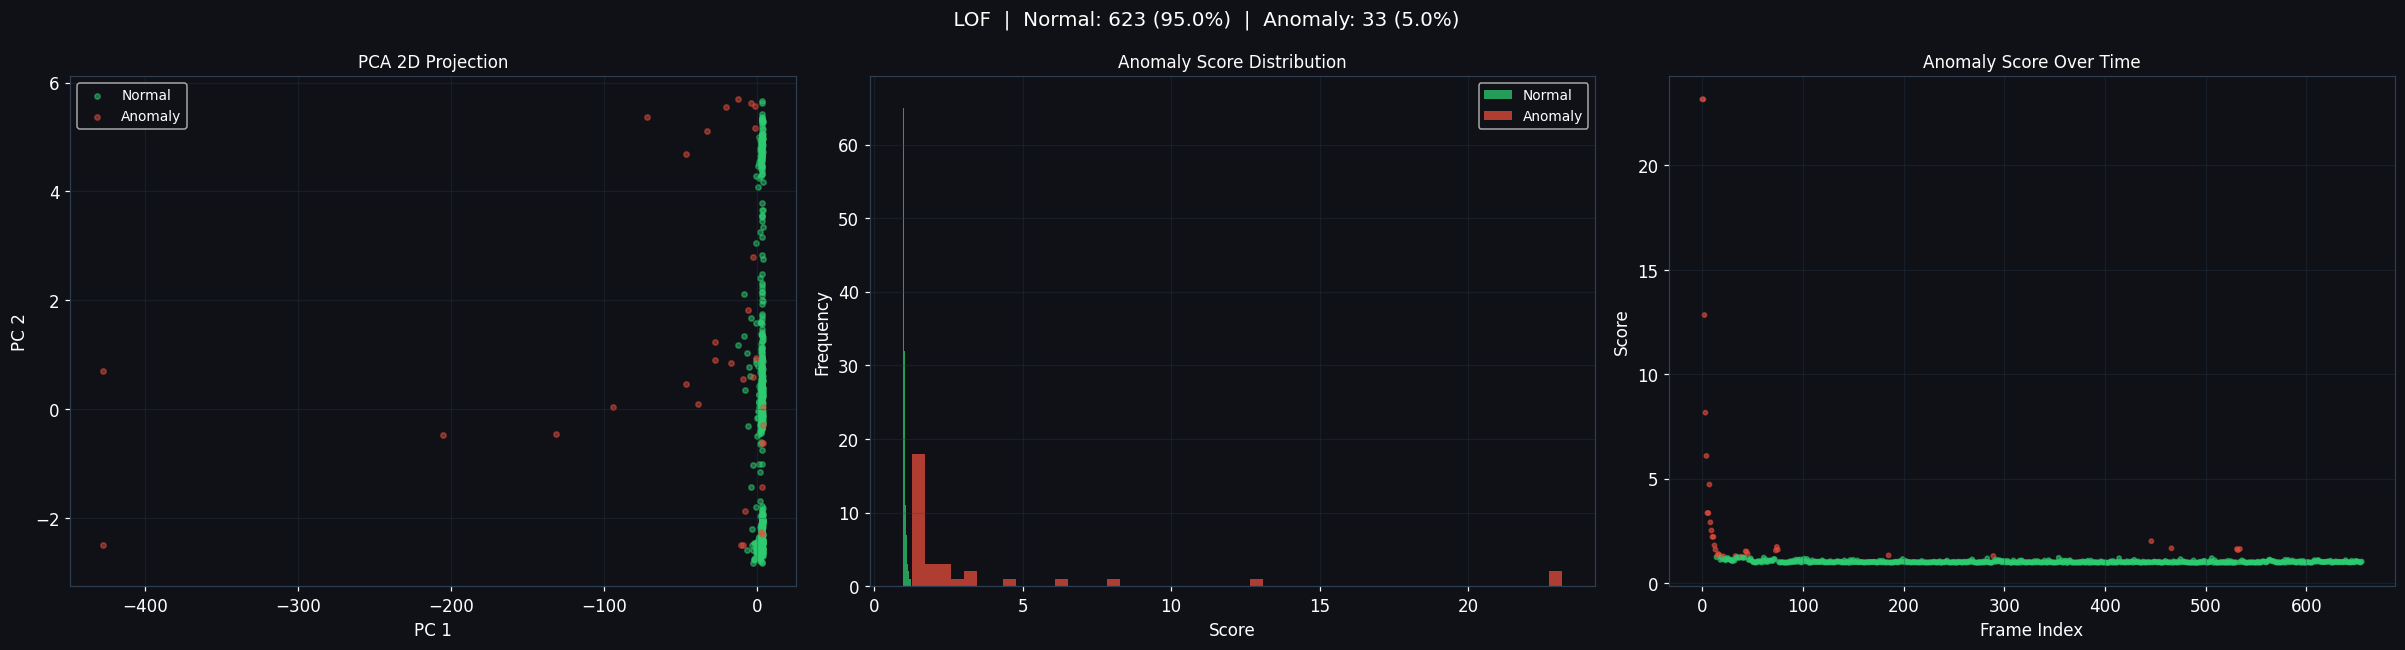

  ✅ LOF evaluation done



In [21]:
pca_vis = PCA(n_components=2, random_state=42)
Xp      = pca_vis.fit_transform(X_scaled)

top3_results = {}

for name in top3_names:
    # retrieve already-fitted model result
    model_result = next(r for r in results if r["Model"] == name)
    preds  = model_result["Preds"]
    scores = model_result["Scores"]
    n_anom = int(preds.sum())
    n_norm = len(preds) - n_anom

    top3_results[name] = {"preds": preds, "scores": scores}

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # ── Plot 1: PCA 2D projection ─────────────────────────────────
    for lbl, val, clr in [("Normal", 0, COLORS["normal"]),
                           ("Anomaly", 1, COLORS["anomaly"])]:
        m = preds == val
        axes[0].scatter(Xp[m, 0], Xp[m, 1],
                        c=clr, label=lbl, alpha=0.5, s=12)
    axes[0].set_title("PCA 2D Projection", fontsize=11)
    axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    # ── Plot 2: Score distribution ────────────────────────────────
    axes[1].hist(scores[preds == 0], bins=50, alpha=0.75,
                 color=COLORS["normal"],  label="Normal")
    axes[1].hist(scores[preds == 1], bins=50, alpha=0.75,
                 color=COLORS["anomaly"], label="Anomaly")
    axes[1].set_title("Anomaly Score Distribution", fontsize=11)
    axes[1].set_xlabel("Score"); axes[1].set_ylabel("Frequency")
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    # ── Plot 3: Score over time ───────────────────────────────────
    c_arr = np.where(preds == 1, COLORS["anomaly"], COLORS["normal"])
    axes[2].scatter(range(len(scores)), scores,
                    c=c_arr, s=8, alpha=0.6)
    axes[2].set_title("Anomaly Score Over Time", fontsize=11)
    axes[2].set_xlabel("Frame Index"); axes[2].set_ylabel("Score")
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        f" {name}  |  "
        f"Normal: {n_norm} ({n_norm/len(preds)*100:.1f}%)  |  "
        f"Anomaly: {n_anom} ({n_anom/len(preds)*100:.1f}%)",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()
    print(f"  ✅ {name} evaluation done\n")

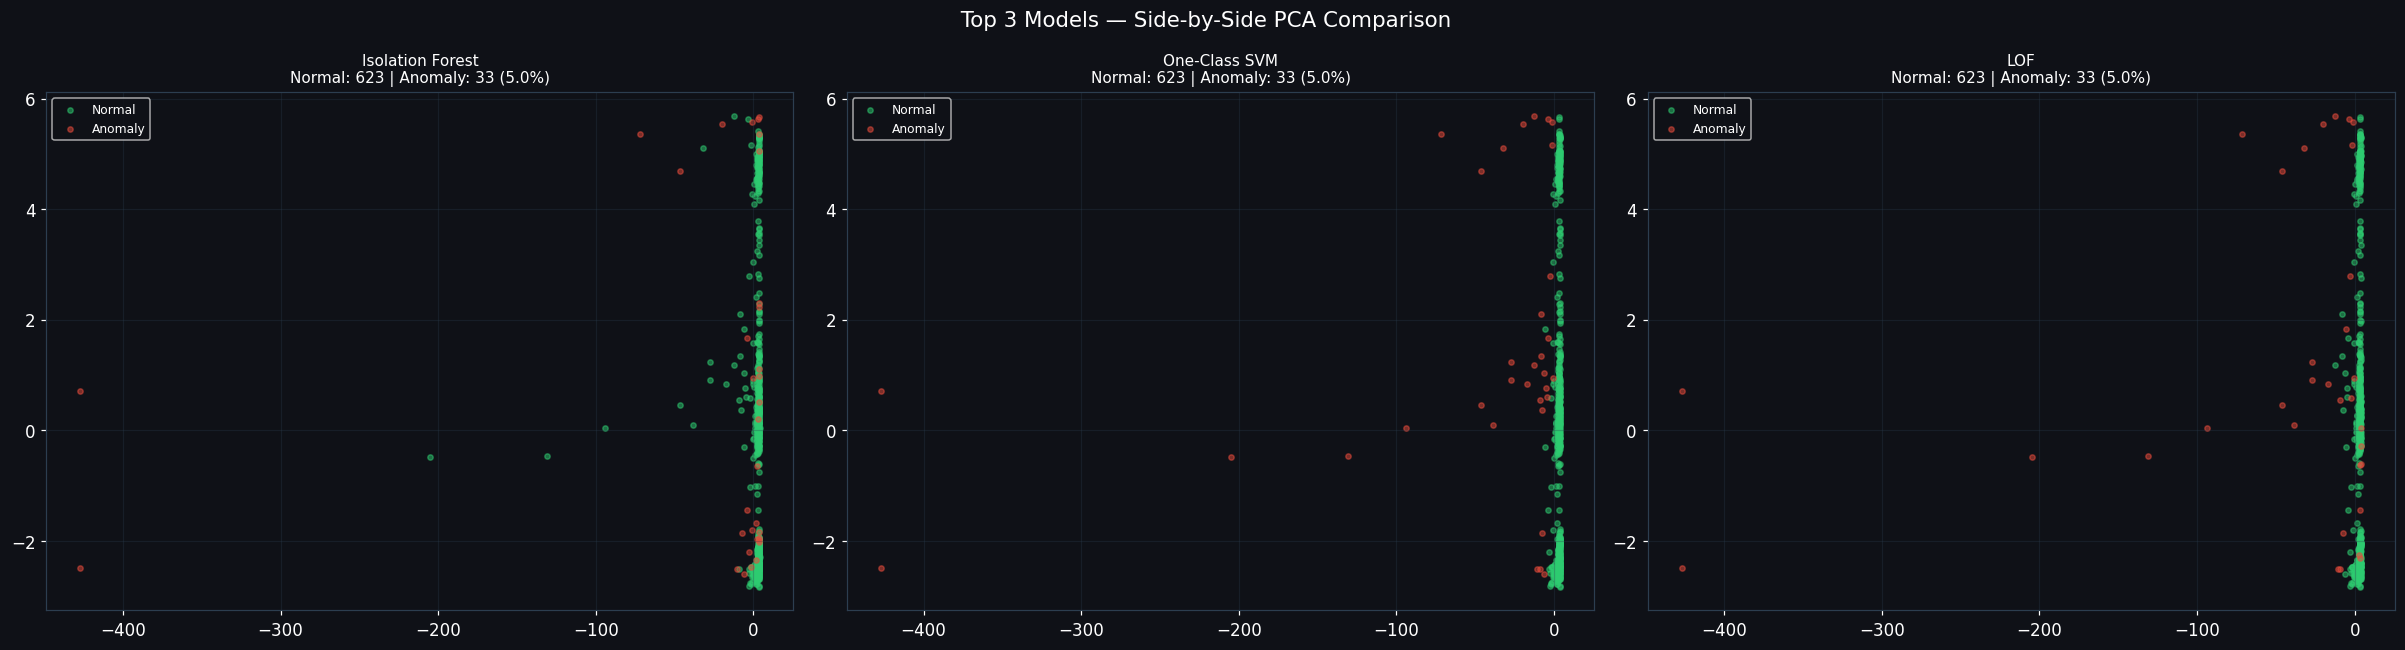

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, name in zip(axes, top3_names):
    preds  = top3_results[name]["preds"]
    n_anom = int(preds.sum())
    n_norm = len(preds) - n_anom
    for lbl, val, clr in [("Normal",  0, COLORS["normal"]),
                           ("Anomaly", 1, COLORS["anomaly"])]:
        m = preds == val
        ax.scatter(Xp[m, 0], Xp[m, 1],
                   c=clr, label=lbl, alpha=0.5, s=12)
    ax.set_title(
        f"{name}\nNormal: {n_norm} | Anomaly: {n_anom} ({n_anom/len(preds)*100:.1f}%)",
        fontsize=10,
    )
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(" Top 3 Models — Side-by-Side PCA Comparison",
             fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
comp_df = pd.DataFrame({
    name: top3_results[name]["preds"].astype(int)
    for name in top3_names
})
comp_df["Ensemble"] = (comp_df.sum(axis=1) >= 2).astype(int)

print("📊 Agreement Summary:")
print(f"{'Model':<25} {'Normal':>8} {'Anomaly':>8} {'Rate%':>7}")
print("─" * 52)
for col in comp_df.columns:
    n_a = comp_df[col].sum()
    n_n = len(comp_df) - n_a
    print(f"{col:<25} {n_n:>8} {n_a:>8} {n_a/len(comp_df)*100:>6.1f}%")

📊 Agreement Summary:
Model                       Normal  Anomaly   Rate%
────────────────────────────────────────────────────
Isolation Forest               623       33    5.0%
One-Class SVM                  623       33    5.0%
LOF                            623       33    5.0%
Ensemble                       630       26    4.0%


In [24]:
m1, m2, m3 = top3_names
only_m1 = ((comp_df[m1]==1)&(comp_df[m2]==0)&(comp_df[m3]==0)).sum()
only_m2 = ((comp_df[m1]==0)&(comp_df[m2]==1)&(comp_df[m3]==0)).sum()
only_m3 = ((comp_df[m1]==0)&(comp_df[m2]==0)&(comp_df[m3]==1)).sum()
two_or_more = (comp_df[[m1,m2,m3]].sum(axis=1) >= 2).sum()
all_normal  = (comp_df[[m1,m2,m3]].sum(axis=1) == 0).sum()

fig = go.Figure(go.Bar(
    x=[f"Only {m1}", f"Only {m2}", f"Only {m3}",
       "≥ 2 Models Agree\n(High Confidence)", "All Normal"],
    y=[only_m1, only_m2, only_m3, two_or_more, all_normal],
    marker_color=["#F39C12","#8E44AD","#1ABC9C",
                  COLORS["anomaly"], COLORS["normal"]],
    text=[only_m1, only_m2, only_m3, two_or_more, all_normal],
    textposition="outside",
))
fig.update_layout(
    title="🤝 Model Agreement — Anomaly Detection Comparison",
    paper_bgcolor=COLORS["bg"], plot_bgcolor=COLORS["bg"],
    font_color="white", height=440,
    yaxis_title="Number of Frames",
)
fig.show()

# Best Model Full Report

In [33]:
best_name   = top3_names[0]
best_preds  = top3_results[best_name]["preds"]
best_scores = top3_results[best_name]["scores"]

n_total = len(best_preds)
n_anom  = int(best_preds.sum())
n_norm  = n_total - n_anom
anom_mask = best_preds == 1

print("=" * 60)
print(f"  BEST MODEL REPORT: {best_name}")
print("=" * 60)
print(f"\n  DETECTION SUMMARY")
print(f"  ├─ Total frames   : {n_total}")
print(f"  ├─ Normal frames  : {n_norm}  ({n_norm/n_total*100:.1f}%)")
print(f"  └─ Anomaly frames : {n_anom}  ({n_anom/n_total*100:.1f}%)")
print(f"\n  ANOMALY SCORE STATISTICS")
print(f"  ├─ Mean     : {best_scores.mean():.4f}")
print(f"  ├─ Std      : {best_scores.std():.4f}")
print(f"  ├─ Min      : {best_scores.min():.4f}")
print(f"  ├─ Max      : {best_scores.max():.4f}")
print(f"  └─ 95th pct : {np.percentile(best_scores, 95):.4f}")

# per-subsystem breakdown
sub_map_report = {
    "EPS":  EPS_FEATS,
    "OBC":  OBC_FEATS,
    "ADCS": ADCS_FEATS,
    "COMM": COMM_FEATS,
}
print(f"\n  ANOMALY BREAKDOWN PER SUBSYSTEM")
print(f"  {'Subsystem':<8} {'Normal Mean':>13} {'Anomaly Mean':>14} {'Diff %':>8}")
print("  " + "─" * 48)
for sub_name, feats in sub_map_report.items():
    sub_f = [c for c in feats if c in df_feat.columns]
    if not sub_f:
        continue
    mn = df_feat.loc[~anom_mask, sub_f].mean().mean()
    ma = df_feat.loc[anom_mask,  sub_f].mean().mean()
    diff = abs(ma - mn) / (abs(mn) + 1e-9) * 100
    print(f"  {sub_name:<8} {mn:>13.2f} {ma:>14.2f} {diff:>7.1f}%")

  BEST MODEL REPORT: Isolation Forest

  DETECTION SUMMARY
  ├─ Total frames   : 656
  ├─ Normal frames  : 623  (95.0%)
  └─ Anomaly frames : 33  (5.0%)

  ANOMALY SCORE STATISTICS
  ├─ Mean     : -0.0514
  ├─ Std      : 0.0272
  ├─ Min      : -0.1072
  ├─ Max      : 0.0329
  └─ 95th pct : -0.0000

  ANOMALY BREAKDOWN PER SUBSYSTEM
  Subsystem   Normal Mean   Anomaly Mean   Diff %
  ────────────────────────────────────────────────
  EPS            1855.98        1976.90     6.5%
  OBC        54389967.41   -76161831.53   240.0%
  ADCS            103.48         119.96    15.9%
  COMM            205.02         189.45     7.6%


In [34]:
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        "Score Distribution",
        "Normal vs Anomaly Count",
        "Score Over Time",
        "PCA 2D Projection",
        "EPS — Feature Deviation (Normal vs Anomaly)",
        "ADCS — Feature Deviation (Normal vs Anomaly)",
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.10,
)

# 1. score distribution
fig.add_trace(go.Histogram(x=best_scores[~anom_mask], name="Normal",
              marker_color=COLORS["normal"], opacity=0.75,
              nbinsx=50), row=1, col=1)
fig.add_trace(go.Histogram(x=best_scores[anom_mask], name="Anomaly",
              marker_color=COLORS["anomaly"], opacity=0.75,
              nbinsx=50), row=1, col=1)

# 2. count bar
fig.add_trace(go.Bar(
    x=["Normal", "Anomaly"],
    y=[n_norm, n_anom],
    marker_color=[COLORS["normal"], COLORS["anomaly"]],
    text=[f"{n_norm}\n({n_norm/n_total*100:.1f}%)",
          f"{n_anom}\n({n_anom/n_total*100:.1f}%)"],
    textposition="outside",
    showlegend=False,
), row=1, col=2)

# 3. score over time
fig.add_trace(go.Scatter(
    y=best_scores,
    mode="markers",
    marker=dict(
        color=np.where(anom_mask, COLORS["anomaly"], COLORS["normal"]),
        size=4,
    ),
    showlegend=False,
), row=2, col=1)

# 4. PCA projection
fig.add_trace(go.Scatter(
    x=Xp[~anom_mask, 0], y=Xp[~anom_mask, 1],
    mode="markers", name="Normal",
    marker=dict(color=COLORS["normal"], size=4, opacity=0.5),
    showlegend=False,
), row=2, col=2)
fig.add_trace(go.Scatter(
    x=Xp[anom_mask, 0], y=Xp[anom_mask, 1],
    mode="markers", name="Anomaly",
    marker=dict(color=COLORS["anomaly"], size=7, symbol="x"),
    showlegend=False,
), row=2, col=2)

# 5. EPS feature deviation
eps_f = [c for c in EPS_FEATS if c in df_feat.columns]
if eps_f:
    diff_eps = (df_feat.loc[anom_mask, eps_f].mean() -
                df_feat.loc[~anom_mask, eps_f].mean()).abs().sort_values()
    fig.add_trace(go.Bar(
        x=diff_eps.values,
        y=[c.replace("EPS_","") for c in diff_eps.index],
        orientation="h",
        marker_color=COLORS["EPS"],
        showlegend=False,
    ), row=3, col=1)

# 6. ADCS feature deviation
adcs_f = [c for c in ADCS_FEATS if c in df_feat.columns]
if adcs_f:
    diff_adcs = (df_feat.loc[anom_mask, adcs_f].mean() -
                 df_feat.loc[~anom_mask, adcs_f].mean()).abs().sort_values()
    fig.add_trace(go.Bar(
        x=diff_adcs.values,
        y=[c.replace("ADCS_","") for c in diff_adcs.index],
        orientation="h",
        marker_color=COLORS["ADCS"],
        showlegend=False,
    ), row=3, col=2)

fig.update_layout(
    height=1050,
    title=f"📋 Full Report — {best_name}  |  "
          f"Anomaly Rate: {n_anom/n_total*100:.1f}%",
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["bg"],
    font_color="white",
    barmode="overlay",
)
fig.show()

# SHAP EXPLAINABILITY

✅ SHAP computed — shape: (656, 49)

  SHAP ROOT CAUSE REPORT — Top 5 Anomaly Frames

  Frame #   0  | Root Cause: COMM_Success_Rate
  Feature                            Value       SHAP
  ────────────────────────────────────────────────────
  COMM_Success_Rate                  0.000    -0.8383
  EPS_Solar_2_Power              2838808.000    -0.1425
  ADCS_MM_X                         -0.862    -0.1413

  Frame #   1  | Root Cause: COMM_Success_Rate
  Feature                            Value       SHAP
  ────────────────────────────────────────────────────
  COMM_Success_Rate                  0.000    -0.8465
  COMM_TX_I_3V3                      1.000    -0.1817
  ADCS_MM_X                          0.545    -0.1508

  Frame #   5  | Root Cause: COMM_Success_Rate
  Feature                            Value       SHAP
  ────────────────────────────────────────────────────
  COMM_Success_Rate                  0.857    -0.2792
  ADCS_Sun_Y                       977.000    -0.2030
  ADCS_Sun_

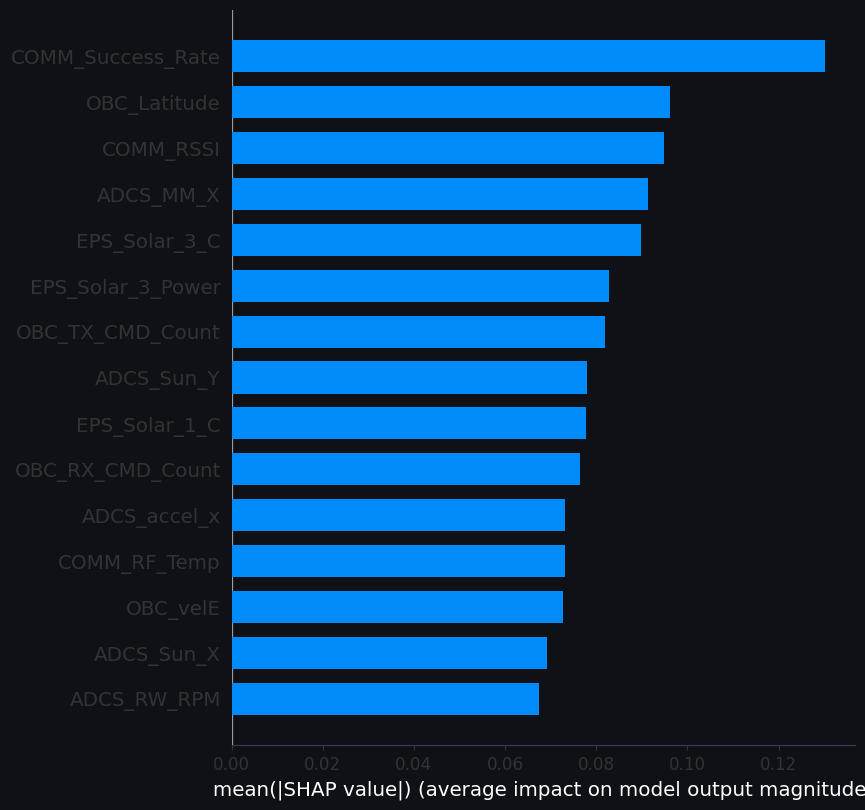

In [35]:
best_fitted = next(r["Fitted"] for r in results if r["Model"] == best_name)

# Requires: best_fitted, X_scaled, FINAL_FEATS, best_preds
!pip install shap -q
import shap

anomaly_explanations = []

if best_name == "Isolation Forest":

    # Build SHAP explainer from the internal sklearn detector
    explainer   = shap.TreeExplainer(best_fitted.detector_)
    shap_values = explainer.shap_values(X_scaled)
    # shap_values shape: (n_samples, n_features)
    # each value = that feature's contribution to the anomaly decision

    print(f"✅ SHAP computed — shape: {shap_values.shape}")

    # Extract explanations for anomaly frames only
    anomaly_indices = np.where(best_preds == 1)[0]

    for idx in anomaly_indices:
        sv = shap_values[idx]

        # Rank features by absolute SHAP value (highest = most responsible)
        contributions = sorted(
            [
                {
                    "feature": feat,
                    "shap":    round(float(sv[i]), 4),
                    "value":   round(float(df_feat.iloc[idx][feat]), 4),
                }
                for i, feat in enumerate(FINAL_FEATS)
            ],
            key=lambda x: abs(x["shap"]),
            reverse=True,
        )

        anomaly_explanations.append({
            "frame_index": int(idx),
            "root_cause":  contributions[0]["feature"],
            "top_3":       contributions[:3],
        })

    # ── Print first 5 as sample ──────────────────────────────
    print("\n" + "=" * 65)
    print("  SHAP ROOT CAUSE REPORT — Top 5 Anomaly Frames")
    print("=" * 65)
    for exp in anomaly_explanations[:5]:
        print(f"\n  Frame #{exp['frame_index']:>4}  "
              f"| Root Cause: {exp['root_cause']}")
        print(f"  {'Feature':<30} {'Value':>9} {'SHAP':>10}")
        print("  " + "─" * 52)
        for c in exp["top_3"]:
            print(f"  {c['feature']:<30} "
                  f"{c['value']:>9.3f} "
                  f"{c['shap']:>10.4f}")

    # ── SHAP Summary Plot ─────────────────────────────────────
    shap.summary_plot(
        shap_values[best_preds == 1],
        features=df_feat.iloc[best_preds == 1],
        feature_names=FINAL_FEATS,
        plot_type="bar",
        show=True,
        max_display=15,
    )

    # ── Most Frequent Root Cause Feature ─────────────────────
    from collections import Counter
    root_cause_counts = Counter(
        [exp["root_cause"] for exp in anomaly_explanations]
    )

    rc_df = pd.DataFrame(
        root_cause_counts.most_common(10),
        columns=["Feature", "Count"]
    )

    fig_rc = px.bar(
        rc_df,
        x="Count", y="Feature", orientation="h",
        color="Count", color_continuous_scale="Reds",
        text="Count",
        title="🔍 Most Frequent Root Cause Feature (SHAP) — All Anomalies",
    )
    fig_rc.update_traces(textposition="outside")
    fig_rc.update_layout(
        paper_bgcolor=COLORS["bg"], plot_bgcolor=COLORS["bg"],
        font_color="white", height=420,
        yaxis=dict(autorange="reversed"),
    )
    fig_rc.show()

else:
    # Fallback: if best model is not Isolation Forest
    # use per-feature mean deviation on scaled data (model-agnostic)
    print(f"⚠️  Best model is '{best_name}' — SHAP not available")
    print("   Using scaled-space deviation as fallback...")

    anomaly_indices = np.where(best_preds == 1)[0]
    normal_mean     = X_scaled[best_preds == 0].mean(axis=0)

    for idx in anomaly_indices:
        deviations = np.abs(X_scaled[idx] - normal_mean)

        contributions = sorted(
            [
                {
                    "feature":   feat,
                    "deviation": round(float(deviations[i]), 4),
                    "value":     round(float(df_feat.iloc[idx][feat]), 4),
                }
                for i, feat in enumerate(FINAL_FEATS)
            ],
            key=lambda x: x["deviation"],
            reverse=True,
        )

        anomaly_explanations.append({
            "frame_index": int(idx),
            "root_cause":  contributions[0]["feature"],
            "top_3":       contributions[:3],
        })

    print(f"✅ Fallback explanations computed "
          f"— {len(anomaly_explanations)} frames")

# Save Model

In [37]:
joblib.dump(best_fitted, "best_anomaly_model.pkl")
joblib.dump(scaler,      "scaler.pkl")

metadata = {
    "model_name":           best_name,
    "features":             FINAL_FEATS,
    "contamination":        CONTAMINATION,
    "n_train_samples":      int(len(X_scaled)),
    "n_features":           int(len(FINAL_FEATS)),
    "anomaly_count":        int(n_anom),
    "anomaly_rate_%":       round(n_anom / n_total * 100, 2),
    "score_mean":           round(float(best_scores.mean()), 4),
    "score_std":            round(float(best_scores.std()),  4),
    "threshold_95pct":      round(float(np.percentile(best_scores, 95)), 4),
    "anomaly_explanations": anomaly_explanations,
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("=" * 55)
print("  FILES SAVED SUCCESSFULLY")
print("=" * 55)
print(f"  Model File    : best_anomaly_model.pkl")
print(f"  Scaler File   : scaler.pkl")
print(f"  Metadata File : model_metadata.json")
print(f"\n  Model Name    : {best_name}")
print(f"  Features      : {len(FINAL_FEATS)}")
print(f"  Anomaly Rate  : {metadata['anomaly_rate_%']}%")
print(f"  Score 95th pct: {metadata['threshold_95pct']}")
print("=" * 55)

files.download("best_anomaly_model.pkl")
files.download("scaler.pkl")
files.download("model_metadata.json")

  FILES SAVED SUCCESSFULLY
  Model File    : best_anomaly_model.pkl
  Scaler File   : scaler.pkl
  Metadata File : model_metadata.json

  Model Name    : Isolation Forest
  Features      : 49
  Anomaly Rate  : 5.03%
  Score 95th pct: -0.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>